<img src="customer_support_analysis.png" style="width:700px; height:400px;">

<div style="background-color:#E0F7FA; color:#004D40; padding:15px; border-radius:8px; margin:10px 0;">
  <span style="color:#00796B; font-size:18px;"><b>Project Overview:</b></span><br><br>
  <b>This project is about analyzing customer support data to understand and improve service quality.</b><br>
  <b>We first separated all the tickets into three groups: resolved (closed), open, and tickets waiting for the customer’s reply.</b><br>
  <b>This helped us study each group better and understand different problems and delays.</b><br>
  <b>We looked at what kind of issues were most common, how long they took to solve, and how happy the customers were.</b><br>
  <b>We focused more on the resolved tickets to check what types took longer and which had low satisfaction ratings.</b><br>
  <b>We used simple visualizations like bar charts and sunburst charts to make the patterns easy to understand.</b><br>
  <b>This project helps support teams improve their speed and service to make customers happier.</b>
</div>


# Importing necessary libraries

In [1]:
# For data manipulation and numerical operation
import pandas as pd
import numpy as np

# importing datetime for handling date and time conversions
from datetime import datetime

# For Data Visulization
import matplotlib.pyplot as plt
import seaborn as sns

# importing warnings to ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# For text processing
import re            
import string 
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import TreebankWordTokenizer


#For Text Visualization
from wordcloud import WordCloud


In [2]:
# Downloading necessary resources for tokenizing and stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Data Loading

In [3]:
df = pd.read_csv("customer_support_tickets.csv")


# Initial Data Inspection

In [4]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


# Exploratory Data Analysis(EDA)

In [5]:
print("Shape of the dataset =", df.shape)

Shape of the dataset = (8469, 17)


<p style="color:#0B6623; font-size:16px;">
    The dataset has a total of <b>8469 rows</b> and <b>17 columns</b>. <br>
    Each row represents one support ticket raised by a customer. <br>
    Each column contains useful information like customer details, ticket type, subject, response time, resolution time, and satisfaction rating. <br>
    This gives us a good amount of data to explore and understand how customer support is performing.
</p>


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic


<p style="color:#0B6623; font-size:16px;">
The dataset contains a total of <b>8469 entries</b> and <b>17 columns</b>. It includes customer details, product information, ticket categories, and resolution-related data. Columns like <b>Customer Age</b> and <b>Ticket ID</b> are numerical, while others such as <b>Customer Name</b>, <b>Product Purchased</b>, <b>Ticket Type</b>, and <b>Ticket Channel</b> are categorical or textual. The <b>Ticket Description</b> column contains detailed text-based information explaining the customer’s issue, which helps in understanding the nature of each support request. Some columns like <b>Resolution</b>, <b>First Response Time</b>, <b>Time to Resolution</b>, and <b>Customer Satisfaction Rating</b> have many missing values, indicating that not all tickets were resolved or rated. This overview helps us understand the structure, data types, and quality of the dataset before we begin further analysis.
</p>


In [7]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [8]:
df.loc[0]

Ticket ID                                                                       1
Customer Name                                                       Marisa Obrien
Customer Email                                         carrollallison@example.com
Customer Age                                                                   32
Customer Gender                                                             Other
Product Purchased                                                      GoPro Hero
Date of Purchase                                                       2021-03-22
Ticket Type                                                       Technical issue
Ticket Subject                                                      Product setup
Ticket Description              I'm having an issue with the {product_purchase...
Ticket Status                                           Pending Customer Response
Resolution                                                                    NaN
Ticket Priority 

In [9]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


<p style="color:#0B6623; font-size:16px;">
This statistical summary helps us understand the distribution of numerical values in the dataset. The dataset includes <b>8469 customer support tickets</b>. <br><br>
The <b>Customer Age</b> ranges from 18 to 70 years, with an average age of around 44. Most customers fall between the ages of 31 (25th percentile) and 57 (75th percentile), indicating that the majority of tickets are raised by adults across a wide age range. <br><br>
The <b>Customer Satisfaction Rating</b> is available for 2769 resolved tickets only. The ratings range from 1 (lowest satisfaction) to 5 (highest satisfaction), with an average rating of approximately 3. This suggests a moderate level of satisfaction overall. Half of the ratings are 3 or below (median = 3), and 75% of them are 4 or below. <br><br>
This summary provides a good foundation for understanding customer demographics and how satisfied they are with the support received.
</p>


# Average Satisfaction Rating Across Age Groups for Resolved Tickets

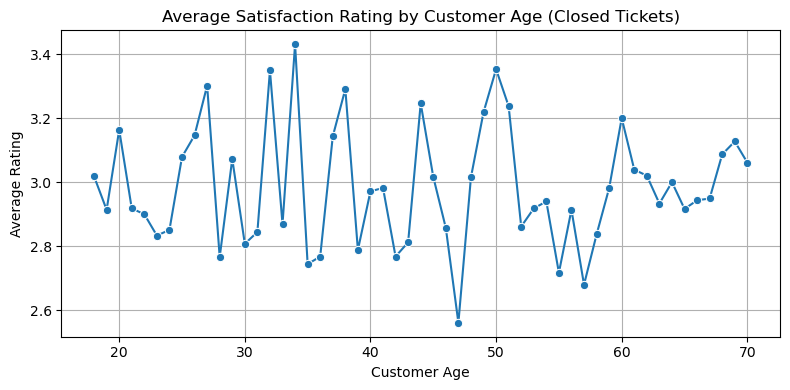

In [10]:
# Filtered closed tickets
closed_tickets = df[df['Ticket Status'] == 'Closed']

# Grouped by Customer Age and calculated average rating
avg_rating_by_age = closed_tickets.groupby('Customer Age')['Customer Satisfaction Rating'].mean().reset_index()

#  Plot
plt.figure(figsize=(8,4))
sns.lineplot(data=avg_rating_by_age, x='Customer Age', y='Customer Satisfaction Rating', marker='o')
plt.title('Average Satisfaction Rating by Customer Age (Closed Tickets)')
plt.xlabel('Customer Age')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This line plot shows how the average <b>customer satisfaction rating</b> varies across different <b>age groups</b> for <b>closed (resolved) tickets</b>.
</p>


# Ticket Status Distribution

In [11]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

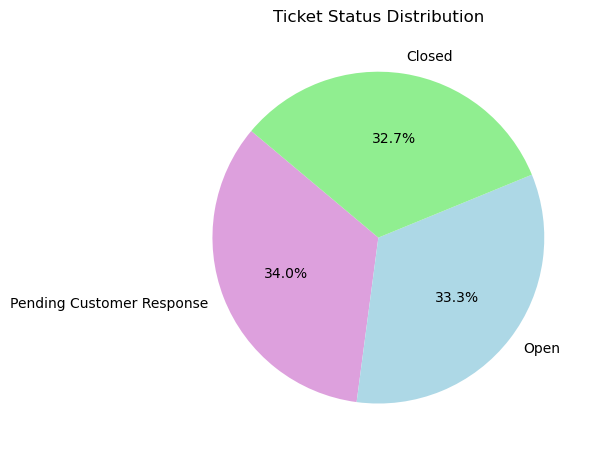

In [12]:
statuses = ['Pending Customer Response', 'Open', 'Closed']
counts = [2881, 2819, 2769]

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=statuses, autopct='%1.1f%%', startangle=140, colors=['plum', 'lightblue', 'lightgreen'])
plt.title('Ticket Status Distribution')
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This pie chart shows the distribution of ticket statuses in the dataset. There are three types of statuses: <b>Pending Customer Response</b>, <b>Open</b>, and <b>Closed</b>. Each slice of the pie represents how many tickets are in each status, with percentages displayed on the chart. The colors used are <b>plum</b>, <b>light blue</b>, and <b>light green</b> for better visualization. This helps us quickly understand how many tickets are still waiting for a customer reply, how many are currently open, and how many have been closed.
</p>


# Ticket Type Distribution

In [13]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

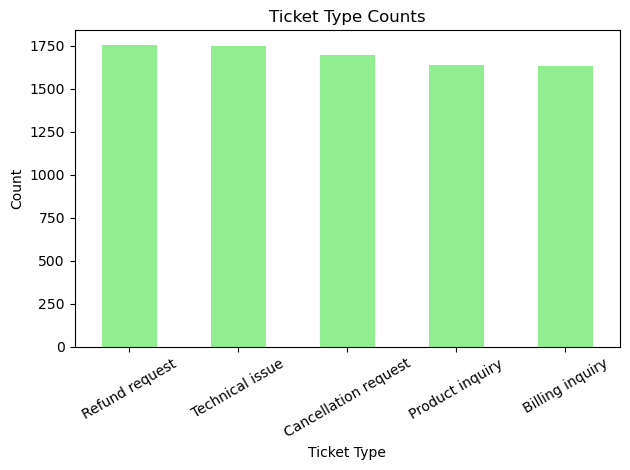

In [14]:
df['Ticket Type'].value_counts().plot(kind='bar', color='lightgreen')


plt.title('Ticket Type Counts')
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This bar chart shows how many tickets belong to each <b>Ticket Type</b>. The main types are <b>Refund request</b>, <b>Technical issue</b>, <b>Cancellation request</b>, <b>Product inquiry</b>, and <b>Billing inquiry</b>. Each green bar’s height tells us the number of tickets for that type. This helps us see which issues customers ask about the most.
</p>


# Ticket Count by Priority

In [15]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

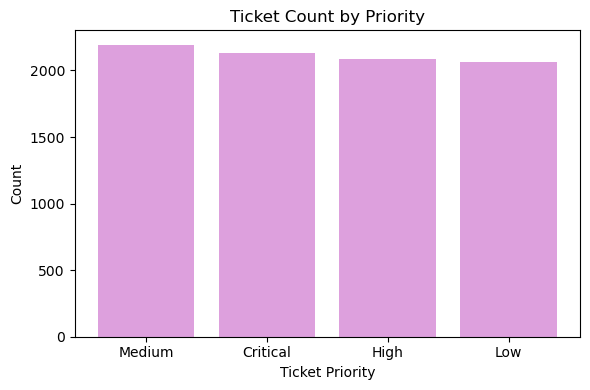

In [16]:
# Data
priorities = ['Medium', 'Critical', 'High', 'Low']
counts = [2192, 2129, 2085, 2063]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(priorities, counts,color='plum')
plt.xlabel('Ticket Priority')
plt.ylabel('Count')
plt.title('Ticket Count by Priority')
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This bar chart shows the number of tickets for each <b>Ticket Priority</b> level. The priorities are <b>Medium</b>, <b>Critical</b>, <b>High</b>, and <b>Low</b>. Each purple bar represents how many tickets fall into each priority category. This helps us understand which priority levels have more tickets that need attention.
</p>


# Ticket Distribution by Communication Channel

In [17]:
df['Ticket Channel'].value_counts()

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

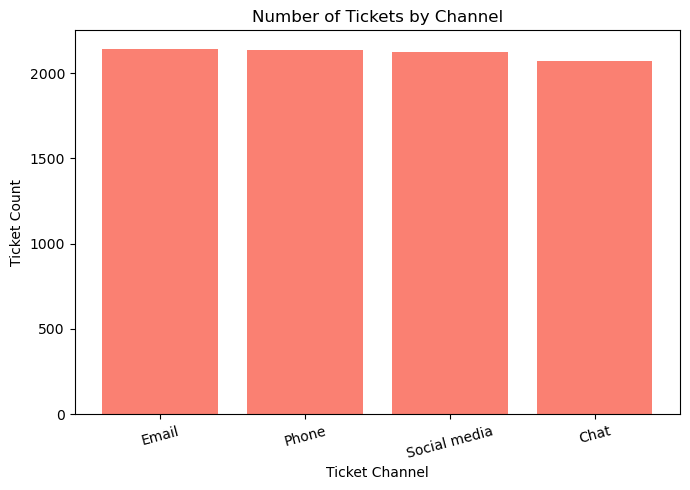

In [18]:
# Data
channels = ['Email', 'Phone', 'Social media', 'Chat']
counts = [2143, 2132, 2121, 2073]

# Plot
plt.figure(figsize=(7, 5))
plt.bar(channels, counts, color='salmon')
plt.xlabel('Ticket Channel')
plt.ylabel('Ticket Count')
plt.title('Number of Tickets by Channel')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This bar chart shows how many tickets were received through different <b>channels</b> such as <b>Email</b>, <b>Phone</b>, <b>Social media</b>, and <b>Chat</b>. Each <b>salmon-colored</b> bar represents the number of tickets from each channel. This helps us see which communication method customers used the most.
</p>


# Customer Issues by Gender and Age Group

In [19]:
df['Customer Gender'].value_counts()

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

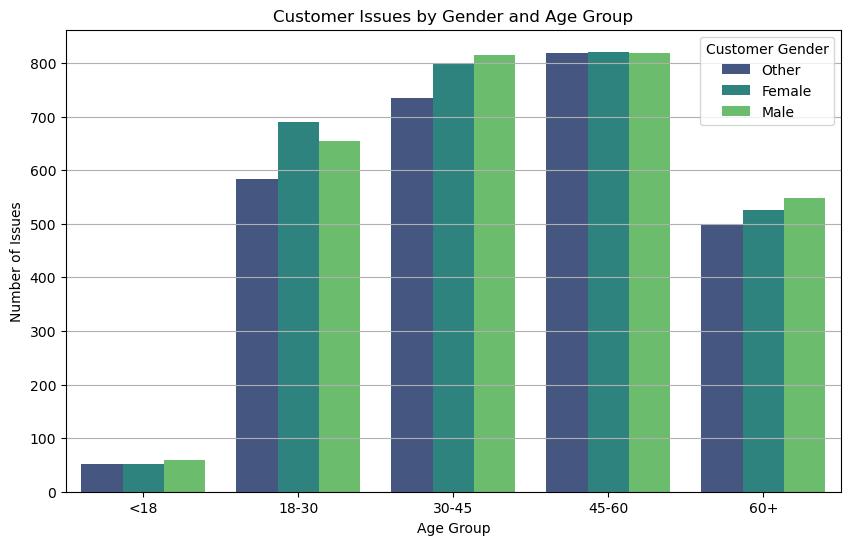

In [20]:
# Creating age bins
df['Age Group'] = pd.cut(df['Customer Age'], bins=[0, 18, 30, 45, 60, 100],
                         labels=['<18', '18-30', '30-45', '45-60', '60+'])

# Plotting count of problems by Gender and Age Group
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age Group', hue='Customer Gender', palette='viridis')
plt.title('Customer Issues by Gender and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Issues')
plt.grid(True, axis='y')
plt.show()

<p style="color:#0B6623; font-size:16px;">
This bar chart shows how many customer issues came from different <b>age groups</b> and how these are split by <b>gender</b>. Age groups include <b>under 18</b>, <b>18–30</b>, <b>30–45</b>, <b>45–60</b>, and <b>60+</b>. Each bar is colored by <b>Customer Gender</b>, so we can compare the number of issues reported by males and females in each age group. This helps us understand which age and gender combinations report more issues.
</p>


# Types of Issues Reported by Different Age Groups

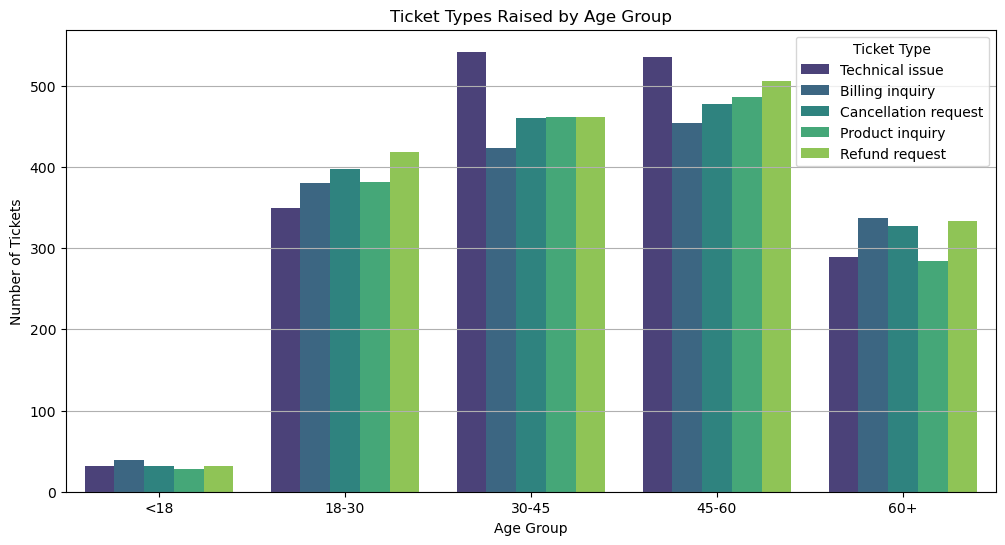

In [21]:
# Creating age bins
df['Age Group'] = pd.cut(df['Customer Age'], bins=[0, 18, 30, 45, 60, 100],
                         labels=['<18', '18-30', '30-45', '45-60', '60+'])

# Plotting Ticket Type vs Age Group
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age Group', hue='Ticket Type', palette='viridis')
plt.title('Ticket Types Raised by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Tickets')
plt.legend(title='Ticket Type')
plt.grid(True, axis='y')
plt.show()

<p style="color:#0B6623; font-size:16px;">
This bar chart shows which <b>age groups</b> raise different types of <b>tickets</b> or problems. The age groups include <b>under 18</b>, <b>18–30</b>, <b>30–45</b>, <b>45–60</b>, and <b>60+</b>. Each colored bar represents a different <b>Ticket Type</b>, such as technical issues, refund requests, or cancellations. From the chart, we can see that most of the problems are reported by people aged <b>30–45</b> and <b>45–60</b>. Among these, <b>Technical issues</b> are the most common. This helps us understand which age groups face more technical problems.
</p>


# Status Counts for Each Kind of Support Ticket

In [22]:
ticket_types = df['Ticket Type'].unique()
statuses = ['Closed', 'Open', 'Pending Customer Response']

for ticket_type in ticket_types:
    print(f"\nTicket Type: {ticket_type}")
    for status in statuses:
        count = df[(df['Ticket Type'] == ticket_type) & (df['Ticket Status'] == status)].shape[0]
        print(f"  {status}: {count}")


Ticket Type: Technical issue
  Closed: 580
  Open: 602
  Pending Customer Response: 565

Ticket Type: Billing inquiry
  Closed: 544
  Open: 539
  Pending Customer Response: 551

Ticket Type: Cancellation request
  Closed: 516
  Open: 582
  Pending Customer Response: 597

Ticket Type: Product inquiry
  Closed: 533
  Open: 532
  Pending Customer Response: 576

Ticket Type: Refund request
  Closed: 596
  Open: 564
  Pending Customer Response: 592


<p style="color:#0B6623; font-size:16px;">
This summary shows how each <b>Ticket Type</b> is spread across different <b>statuses</b> like <b>Closed</b>, <b>Open</b>, and <b>Pending Customer Response</b>. For example, <b>Technical issues</b> have almost equal counts across all three statuses, while <b>Cancellation requests</b> and <b>Refund requests</b> also show high numbers in the <b>Pending</b> category. This helps us understand the progress and resolution stage of each type of customer problem.
</p>


# Status Distribution for Ticket Type Issue

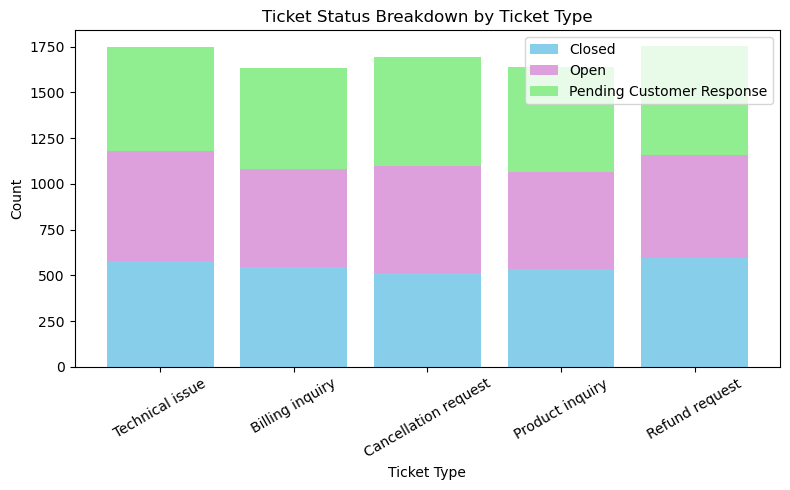

In [23]:
# Data
ticket_types = ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
closed = [580, 544, 516, 533, 596]
open_status = [602, 539, 582, 532, 564]
pending = [565, 551, 597, 576, 592]

# Creating a stacked bar plot
plt.figure(figsize=(8, 5))

plt.bar(ticket_types, closed, label='Closed', color='skyblue')
plt.bar(ticket_types, open_status, bottom=closed, label='Open', color='plum')
plt.bar(ticket_types, pending, bottom=[i+j for i,j in zip(closed, open_status)], label='Pending Customer Response', color='lightgreen')


plt.title('Ticket Status Breakdown by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This stacked bar chart shows how different <b>ticket types</b> are divided into <b>Closed</b>, <b>Open</b>, and <b>Pending Customer Response</b> statuses. Each bar is split into three colored sections, helping us easily compare the progress of each type. For example, <b>Technical issues</b and <b>Refund requests</b> have many tickets still <b>Open</b> or <b>Pending</b>. This chart gives a clear view of how well different issues are being resolved.
</p>


# Ticket Priority Breakdown by Ticket Type

In [24]:
ticket_types = df['Ticket Type'].unique()
priorities = ['Low', 'Medium', 'High', 'Critical']

for ticket_type in ticket_types:
    print(f"\nTicket Type: {ticket_type}")
    for priority in priorities:
        count = df[(df['Ticket Type'] == ticket_type) & (df['Ticket Priority'] == priority)].shape[0]
        print(f"  Priority {priority}: {count}")



Ticket Type: Technical issue
  Priority Low: 413
  Priority Medium: 437
  Priority High: 458
  Priority Critical: 439

Ticket Type: Billing inquiry
  Priority Low: 398
  Priority Medium: 434
  Priority High: 382
  Priority Critical: 420

Ticket Type: Cancellation request
  Priority Low: 414
  Priority Medium: 460
  Priority High: 398
  Priority Critical: 423

Ticket Type: Product inquiry
  Priority Low: 398
  Priority Medium: 441
  Priority High: 399
  Priority Critical: 403

Ticket Type: Refund request
  Priority Low: 440
  Priority Medium: 420
  Priority High: 448
  Priority Critical: 444


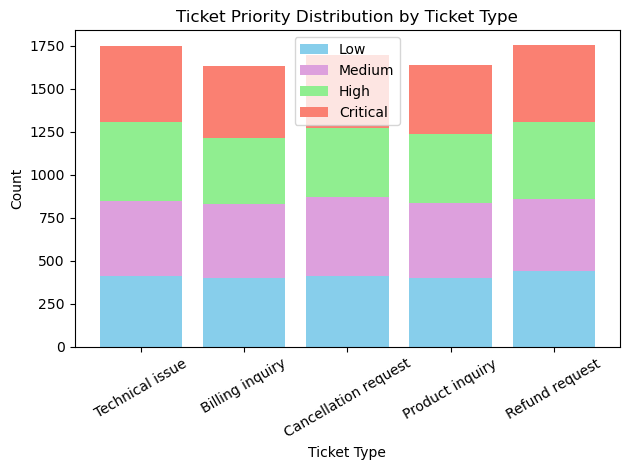

In [25]:
# Data
ticket_types = ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
low = [413, 398, 414, 398, 440]
medium = [437, 434, 460, 441, 420]
high = [458, 382, 398, 399, 448]
critical = [439, 420, 423, 403, 444]

# Plotting
plt.bar(ticket_types, low, label='Low', color='skyblue')
plt.bar(ticket_types, medium, bottom=low, label='Medium', color='plum')
plt.bar(ticket_types, high, bottom=[i+j for i,j in zip(low, medium)], label='High', color='lightgreen')
plt.bar(ticket_types, critical, bottom=[i+j+k for i,j,k in zip(low, medium, high)], label='Critical', color='salmon')

plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.title('Ticket Priority Distribution by Ticket Type')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

<p style="color:#0B6623; font-size:16px;">
This summary shows how different <b>ticket types</b> are spread across <b>priority levels</b> — <b>Low</b>, <b>Medium</b>, <b>High</b>, and <b>Critical</b>. For example, <b>Technical issues</b> and <b>Refund requests</b> have a high number of <b>High</b> and <b>Critical</b> priority tickets, meaning they are considered more urgent. On the other hand, tickets like <b>Billing inquiry</b> and <b>Product inquiry</b> also have a balanced spread across all priorities. This helps us understand how serious or urgent different types of problems are.
</p>

# Ticket Resolution and Urgency Overview by Category

In [26]:
ticket_types = df['Ticket Type'].unique()
priorities = ['Low', 'Medium', 'High', 'Critical']
statuses = ['Closed', 'Open', 'Pending Customer Response']

for ticket_type in ticket_types:
    print(f"\nTicket Type: {ticket_type}")
    for priority in priorities:
        print(f"  Priority: {priority}")
        for status in statuses:
            count = df[
                (df['Ticket Type'] == ticket_type) &
                (df['Ticket Priority'] == priority) &
                (df['Ticket Status'] == status)
            ].shape[0]
            print(f"  {status}: {count}")



Ticket Type: Technical issue
  Priority: Low
  Closed: 138
  Open: 151
  Pending Customer Response: 124
  Priority: Medium
  Closed: 138
  Open: 153
  Pending Customer Response: 146
  Priority: High
  Closed: 157
  Open: 152
  Pending Customer Response: 149
  Priority: Critical
  Closed: 147
  Open: 146
  Pending Customer Response: 146

Ticket Type: Billing inquiry
  Priority: Low
  Closed: 133
  Open: 137
  Pending Customer Response: 128
  Priority: Medium
  Closed: 133
  Open: 131
  Pending Customer Response: 170
  Priority: High
  Closed: 135
  Open: 134
  Pending Customer Response: 113
  Priority: Critical
  Closed: 143
  Open: 137
  Pending Customer Response: 140

Ticket Type: Cancellation request
  Priority: Low
  Closed: 105
  Open: 143
  Pending Customer Response: 166
  Priority: Medium
  Closed: 142
  Open: 154
  Pending Customer Response: 164
  Priority: High
  Closed: 124
  Open: 151
  Pending Customer Response: 123
  Priority: Critical
  Closed: 145
  Open: 134
  Pending C

<p style="font-size:16px; color:green;">
This detailed breakdown presents how each <b>ticket type</b> is distributed across various <b>priority levels</b> (<b>Low</b>, <b>Medium</b>, <b>High</b>, <b>Critical</b>) and <b>ticket statuses</b> (<b>Closed</b>, <b>Open</b>, <b>Pending Customer Response</b>). It shows the resolution trends and urgency patterns of different customer issues.
<br><br>
For example, <b>Technical issues</b> and <b>Refund requests</b> show higher numbers in the <b>High</b> and <b>Critical</b> categories, indicating urgency and critical attention needed. <b>Cancellation requests</b> have more <b>Pending Customer Response</b> statuses, especially in <b>Low</b> and <b>Medium</b> priorities, which could signal a need for better follow-up processes. <b>Billing inquiry</b> where priority is <b>Medium</b> also shows a high number of <b>Pending Customer Response</b>.
<br><br>
This summary helps in identifying which <b>issue types</b> often remain <b>unresolved</b>, their <b>urgency level</b>, and where <b>resource allocation</b> or <b>customer engagement</b> can be improved.
</p>



# Ticket Status Distribution by Ticket Priority

In [27]:
priorities = df['Ticket Priority'].unique()
statuses = ['Closed', 'Open', 'Pending Customer Response']

for priority in priorities:
    print(f"\nTicket Priority: {priority}")
    for status in statuses:
        count = df[(df['Ticket Priority'] == priority) & (df['Ticket Status'] == status)].shape[0]
        print(f"  {status}: {count}")


Ticket Priority: Critical
  Closed: 726
  Open: 692
  Pending Customer Response: 711

Ticket Priority: Low
  Closed: 644
  Open: 696
  Pending Customer Response: 723

Ticket Priority: High
  Closed: 705
  Open: 704
  Pending Customer Response: 676

Ticket Priority: Medium
  Closed: 694
  Open: 727
  Pending Customer Response: 771


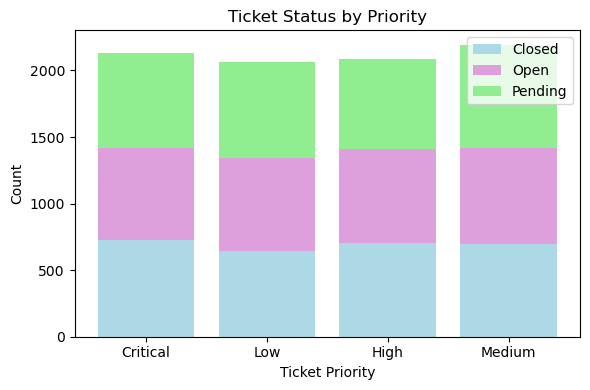

In [28]:
# Data
priorities = ['Critical', 'Low', 'High', 'Medium']
closed = [726, 644, 705, 694]
open_ = [692, 696, 704, 727]
pending = [711, 723, 676, 771]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(priorities, closed, label='Closed', color='lightblue')
plt.bar(priorities, open_, bottom=closed, label='Open', color='plum')
plt.bar(priorities, pending, bottom=[closed[i] + open_[i] for i in range(len(priorities))], label='Pending', color='lightgreen')
plt.xlabel('Ticket Priority')
plt.ylabel('Count')
plt.title('Ticket Status by Priority')
plt.legend()
plt.tight_layout()
plt.show()

# Missing Data Summary in the Dataset

In [29]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
Age Group                          0
dtype: int64

<p style="color:#0B6623; font-size:16px;">
The dataset has no missing values in columns like <b>Ticket ID</b>, <b>Customer Name</b>, <b>Customer Age</b>, and <b>Ticket Status</b>. However, several important columns have many missing values: <b>Resolution</b>, <b>Time to Resolution</b>, and <b>Customer Satisfaction Rating</b> each have <b>5700 missing entries</b>. Also, <b>First Response Time</b> has <b>2819 missing entries</b>. This indicates that many tickets may not have been resolved or rated yet, affecting the completeness of some analyses.
</p>


In [30]:
# Checking missing values count and percentage
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Combining into one DataFrame for clear view
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Filtering only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

# Showing the result
print(missing_df)


                              Missing Count  Missing %
Resolution                             5700  67.304286
Time to Resolution                     5700  67.304286
Customer Satisfaction Rating           5700  67.304286
First Response Time                    2819  33.286102


# Visual Representation Of Missing Values

<Axes: >

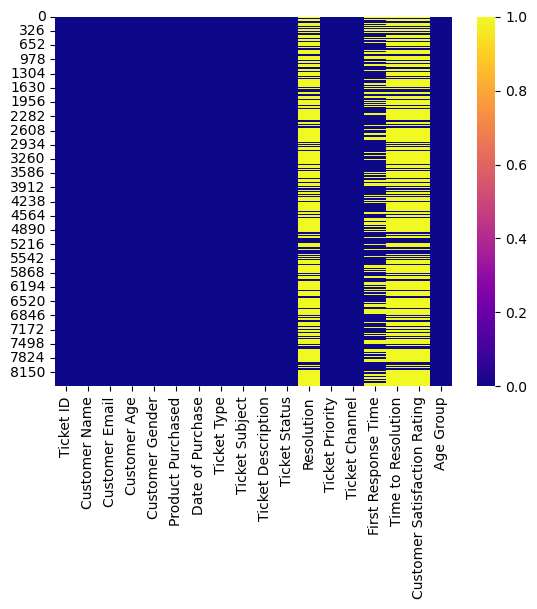

In [31]:
sns.heatmap(df.isnull(), cmap='plasma')

# DateTime Conversion

In [32]:
# converting date columns to datetime format
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

<p style="color:green;">
  In this step, I converted the 'Date of Purchase', 'First Response Time', and 'Time to Resolution' columns into datetime format. This ensures that I can perform time-based operations like calculating delays and resolution times.
</p>


# Seperating Data into Resolved and Unresolved

In [33]:
df['Is Resolved'] = df['Time to Resolution'].notnull()


In [34]:
df['Is Resolved'].value_counts()


Is Resolved
False    5700
True     2769
Name: count, dtype: int64

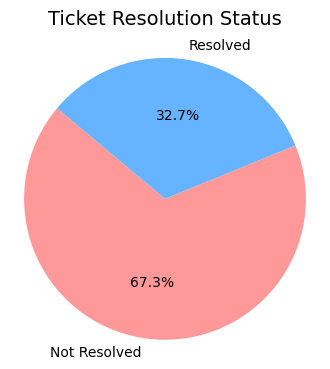

In [35]:
#plotting the resolved and unresolved data
resolved_counts = df['Is Resolved'].value_counts()


labels = ['Not Resolved', 'Resolved']  

# Pie chart
plt.figure(figsize=(4, 4))
plt.pie(resolved_counts, 
        labels=labels, 
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'], 
        startangle=140)
plt.title('Ticket Resolution Status', y=1.04, fontsize=14)
plt.axis('equal')  
plt.show()

In [36]:
df[df['Is Resolved'] == False]['Ticket Subject'].value_counts().head(20)

Ticket Subject
Refund request              398
Delivery problem            383
Software bug                375
Installation support        372
Product compatibility       372
Payment issue               370
Battery life                369
Hardware issue              364
Product setup               346
Data loss                   344
Cancellation request        339
Peripheral compatibility    338
Account access              338
Network problem             338
Product recommendation      331
Display issue               323
Name: count, dtype: int64

# Text Cleaning and Preprocessing

In [37]:
tokenizer = TreebankWordTokenizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = tokenizer.tokenize(text)  
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['Cleaned_Description'] = df['Ticket Description'].apply(clean_text)

In [38]:
# Combined all cleaned text
all_words = ' '.join(df['Cleaned_Description']).split()

# Getting most common words
word_freq = Counter(all_words)
print(word_freq.most_common(20))

[('productpurchased', 14048), ('issue', 11530), ('im', 10287), ('please', 8808), ('assist', 6250), ('ive', 6001), ('problem', 2285), ('product', 2270), ('data', 1654), ('software', 1552), ('account', 1461), ('steps', 1390), ('noticed', 1208), ('persists', 1178), ('help', 1176), ('resolve', 1165), ('update', 1155), ('would', 1122), ('device', 1106), ('unable', 1088)]


# Word Cloud of Cleaned Ticket Descriptions

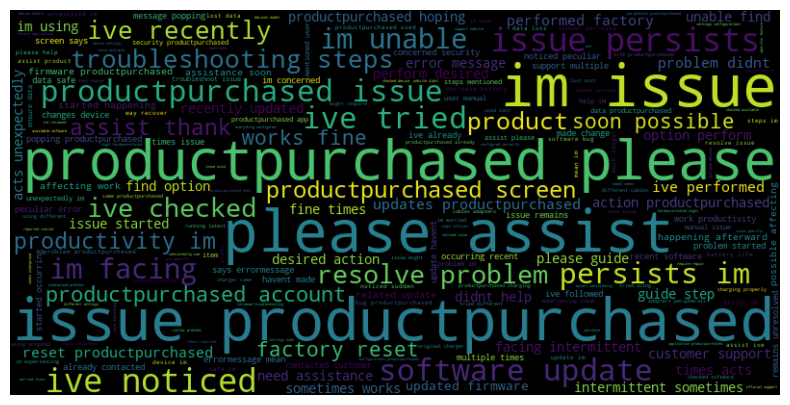

In [39]:
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(df['Cleaned_Description']))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Calculating Response Delay and Resolution Time in Hours

In [40]:
df['Response Delay (in hours)'] = (df['First Response Time'] - df['Date of Purchase']).dt.total_seconds() / 3600
df['Resolution Time (in hours)'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600


<p style="color:green;">
  I created two new columns ... 'Response Delay' to track the time between purchase and first response, and 'Resolution Time' to measure the time between first response and issue resolution. Both help in analyzing the support team's response and resolution speed.
</p>


# Frequency of Resolved Tickets by Ticket Type

In [41]:
# Filter resolved tickets with valid (positive) resolution time
resolved_tickets = df[(df['Is Resolved'] == True) & (df['Resolution Time (in hours)'] > 0)]

# Count the frequency of each Ticket Type
resolved_type_counts = resolved_tickets['Ticket Type'].value_counts()

# Display
print("Resolved Ticket Type Frequency:")
print(resolved_type_counts)


Resolved Ticket Type Frequency:
Ticket Type
Technical issue         305
Refund request          303
Billing inquiry         273
Cancellation request    265
Product inquiry         256
Name: count, dtype: int64


# Frequency of Active Unresolved Tickets by Ticket Type (Excluding Pending Customer Response) / for Open Ticket

In [42]:
# Filtering unresolved tickets where Time to Resolution is NaT and First Response is NOT null (support has replied)
unresolved_pending_customer = df[
    (df['Is Resolved'] == False) &
    (df['Time to Resolution'].isna()) &
    (df['First Response Time'].notna())
]

# Now excluding them to focus on active unresolved tickets
active_unresolved = df[
    (df['Is Resolved'] == False) &
    (~df.index.isin(unresolved_pending_customer.index))
]

# Counting Ticket Types
unresolved_type_counts = active_unresolved['Ticket Type'].value_counts()

# Displaying
print("\nUnresolved Ticket Type Frequency (excluding pending customer reply):")
print(unresolved_type_counts)


Unresolved Ticket Type Frequency (excluding pending customer reply):
Ticket Type
Technical issue         602
Cancellation request    582
Refund request          564
Billing inquiry         539
Product inquiry         532
Name: count, dtype: int64


# Proceeding To Handle Data Where Customer Response is Pending

In [43]:
# Checking how many days customer has not responded after support replied, to auto-close if >90 days

# Assuming today's date for reference
today = pd.to_datetime("today")

# Calculating how long customer hasn't responded (only if resolution is NaT)
df['Customer_Response_Pending_Days'] = df.apply(
    lambda row: (today - row['First Response Time']).days if pd.isna(row['Time to Resolution']) else 0,
    axis=1
)

# Marking tickets for auto-closing if no customer response in 90+ days
df['Auto_Close'] = df['Customer_Response_Pending_Days'].apply(lambda x: True if x > 90 else False)

In [44]:
# Getting all tickets where customer didn't respond for over 90 days

auto_close_tickets = df[df['Auto_Close'] == True]

In [45]:
# Removing tickets with negative resolution time

df_filtered = df[df['Resolution Time (in hours)'] >= 0]

# Data Saved into a New CSV file

In [46]:
# Counting  tickets to be auto-closed

print("Tickets to auto-close:", auto_close_tickets.shape[0])

Tickets to auto-close: 2881


In [47]:
# Exporting auto-closable tickets to CSV

auto_close_tickets.to_csv("auto_close_tickets.csv", index=False)

In [48]:
df.shape

(8469, 24)

# Resolved data with Positive Resolution Time (in hours)

In [49]:
closed_positive_res_time = df[(df['Time to Resolution'].notna()) & (df['Resolution Time (in hours)'] > 0)]
print("Number of closed tickets with positive resolution time:", closed_positive_res_time.shape[0])


Number of closed tickets with positive resolution time: 1402


<p style="color:green;">
We found that after calculating the resolution time in hours, some data have negative resolution times. This might be due to incorrect data entry or differences in time zones.
</p>


In [50]:
# Filtering the dataframe where Ticket Status is 'Open'
open_tickets_df = df[df['Ticket Status'] == 'Open']

# Saved this filtered data to CSV
open_tickets_df.to_csv('open_tickets.csv', index=False)

print(f"Saved {len(open_tickets_df)} rows where Ticket Status is 'Open' to open_tickets.csv")


Saved 2819 rows where Ticket Status is 'Open' to open_tickets.csv


In [51]:
#Saving the data of resolved ticket to a new CSV

resolved_tickets = df[df['Is Resolved'] == True]
resolved_tickets.to_csv('resolved_tickets.csv', index=False)
print(f"Saved {resolved_tickets.shape[0]} resolved tickets to 'resolved_tickets.csv'")


Saved 2769 resolved tickets to 'resolved_tickets.csv'


<div style="background-color:#4B0082; color:white; padding:15px; margin:10px 0; font-size:16px; line-height:1.6;">
  <strong>How Can We Improve Response Time for Customer Ticket Data Analysis?</strong><br><br>
  Improving response time helps build trust and increases customer satisfaction. Below are several suggestions with their explanations:
</div>

<div style="background-color:#800000; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>1. Analyze Ticket Priority and Status Carefully</strong><br>
  We noticed that ticket types like <strong>Technical Issue</strong> and <strong>Refund Request</strong> mostly appear in <em>High</em> and <em>Critical</em> priority. So, we must assign more skilled agents and faster channels (like phone or chatbot) to such tickets. This reduces waiting time and improves customer trust.
</div>

<div style="background-color:#006400; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>2. Build a Smart Chatbot for Common Queries</strong><br>
  Many tickets are simple and repetitive. For example, "How do I reset my password?" or "Where can I track my order?" A chatbot can instantly answer these without human help. If the customer is not satisfied, the chatbot can connect them to live agents.
</div>

<div style="background-color:#2F4F4F; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>3. Improve Help Section with Pre-Answered FAQs</strong><br>
  Add a clearly visible help section with common questions and answers. If users can find answers themselves, they won’t create new tickets. This reduces overall ticket volume and allows support teams to focus on urgent problems.
</div>

<div style="background-color:#483D8B; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>4. Handle Elderly Customers with Care</strong><br>
  From our data, we noticed many tickets were created by elderly users. They may struggle with technology. So, we should offer them priority service, a dedicated helpline, and simplified instructions. Also, friendly tone and patient agents make a big difference.
</div>

<div style="background-color:#FF8C00; color:#000000; padding:15px; margin:10px 0;">
  <strong>5. Monitor Resolution and Response Delays</strong><br>
  We created two columns: <strong>Response Delay (in hours)</strong> and <strong>Resolution Time (in hours)</strong>. This helped us find tickets that were answered too late. We should focus on those agents or ticket types that usually take longer and improve the process or training.
</div>

<div style="background-color:#008B8B; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>6. Use Automation to Close Unresponsive Tickets</strong><br>
  In the <strong>auto_close_tickets.csv</strong> file, we found tickets where the <strong>customer support team has already replied</strong> to the customer's issue, but the <strong>customer did not reply back</strong> after that.<br><br>
  To handle such cases, we decided to set a <strong>response deadline of 90 days</strong>. If the customer does not respond within these 90 days, we <strong>automatically mark the ticket as resolved</strong> and close it. <br><br>
  This helps us keep the system clean and avoids waiting on tickets that are likely no longer active. If the customer still needs help, they can always <strong>raise a new ticket later</strong> and get support again.
</div>


<div style="background-color:#DC143C; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>7. Check Data Quality – Watch for Errors</strong><br>
  In <strong>resolved_tickets.csv</strong>, some tickets showed negative resolution times. This might be due to wrong data entry or different time zones. We should set up checks to flag and fix such errors in real time to ensure accurate reporting.
</div>

<div style="background-color:#1E90FF; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>8. Focus on Unresolved Tickets Without Response</strong><br>
  In <strong>open_tickets.csv</strong>, tickets were left without any reply from support. These need immediate attention. Managers should review them regularly and assign them higher priority to avoid customer dissatisfaction.
</div>

<div style="background-color:#8B4513; color:#FFFFFF; padding:15px; margin:10px 0;">
  <strong>Conclusion</strong><br>
  After analyzing the entire dataset, we categorized tickets into three groups:<br><br>
  <strong>✔ Resolved Tickets:</strong> Closed successfully, though some had issues like wrong timestamps.<br>
  <strong>✔ Unresolved Tickets:</strong> Still open without a solution — need urgent action.<br>
  <strong>✔ Pending Customer Response:</strong> Support team has replied, but waiting for customer’s reply. These are set to auto-close after 90 days.<br><br>
  Our main focus should be on:<br>
  ➤ Responding quicker to <strong>High/Critical</strong> priority issues<br>
  ➤ Assisting <strong>elderly customers</strong> better<br>
  ➤ Using <strong>chatbots</strong> and <strong>FAQs</strong> to reduce repetitive tickets<br>
  ➤ Regularly checking for <strong>data errors</strong> and cleaning up inactive tickets<br>
  ➤ Ensuring no ticket goes <strong>unattended</strong> for long<br>
</div>
